This code identifies events in the sphere which are coincident with events in the veto system!

In [1]:
#import the datasets
import pandas as pd
import matplotlib.pyplot as plt # https://matplotlib.org/
import numpy as np # http://www.numpy.org/


#load data
filename = "Ac20h000.csv"
df = pd.read_csv(filename)

#keep columns we care about
df = df[['event', 'anode', 'amplitude', 'risetime']].copy()

#ensure numeric
df['amplitude'] = pd.to_numeric(df['amplitude'], errors='coerce')
df['risetime'] = pd.to_numeric(df['risetime'], errors='coerce')

amp_df = df.pivot_table(index='event', columns='anode', values='amplitude', aggfunc='first')
amp_df = amp_df.rename(columns={col: f"{col}_amplitude" for col in amp_df.columns})

rise_df = df.pivot_table(index='event', columns='anode', values='risetime', aggfunc='first')
rise_df = rise_df.rename(columns={col: f"{col}_risetime" for col in rise_df.columns})

#combine into one dataframe
event_df = pd.concat([amp_df, rise_df], axis=1).reset_index()

#check
#print(event_df.head())
#print("Columns:", event_df.columns.tolist())

#identify anode with highest amplitude for each anode
sphere_amplitude_cols = [col for col in event_df.columns if col.endswith('_amplitude') and not col.startswith('Laser')]
event_df['max_anode'] = event_df[sphere_amplitude_cols].idxmax(axis=1)
#identify which risetime corresponds to this anode and event
event_df['max_anode'] = event_df['max_anode'].str.replace('_amplitude', '', regex=False)
event_df['risetime'] = [event_df.loc[i, f"{anode}_risetime"] if pd.notna(anode) else np.nan for i, anode in event_df['max_anode'].items()]

#sum together all of the sphere anode amplitudes and create a new column of 'summed_amplitude'
event_df['summed_amplitude'] = event_df[sphere_amplitude_cols].sum(axis=1)

print(event_df.columns)

Index(['event', 'F0_amplitude', 'F1_amplitude', 'F2_amplitude', 'F3_amplitude',
       'F4_amplitude', 'F5_amplitude', 'Laser_amplitude', 'N1_amplitude',
       'N2_amplitude', 'N3_amplitude', 'N4_amplitude', 'N5_amplitude',
       'F0_risetime', 'F1_risetime', 'F2_risetime', 'F3_risetime',
       'F4_risetime', 'F5_risetime', 'Laser_risetime', 'N1_risetime',
       'N2_risetime', 'N3_risetime', 'N4_risetime', 'N5_risetime', 'max_anode',
       'risetime', 'summed_amplitude'],
      dtype='object', name='anode')


In [2]:
#some of the veto rows will be empty - only keep if amplitude above some nominal noise, say 200ADU
events_which_trigger_veto = event_df[event_df['Laser_amplitude'].abs() > 200] #these are the muons
#remove events which trigger the veto from the sphere data frame
events_after_veto_df = event_df[~event_df['event'].isin(events_which_trigger_veto['event'])] #this has (some) muons removed

print('all events')
print(len(event_df))
print(event_df.head())


print('muon events')
print(len(events_which_trigger_veto))
print(events_which_trigger_veto.head())


print('events left after veto')
print(len(events_after_veto_df))
print(events_after_veto_df.head())

all events
65287
anode  event  F0_amplitude  F1_amplitude  F2_amplitude  F3_amplitude  \
0          0    146.722222    -30.833333    -12.285714    -93.305785   
1          1    -61.166667    -43.333333     57.277778     65.666667   
2          2    -23.666667    -18.333333     51.222222     28.277778   
3          3    -29.500000    -21.111111    -45.888889    -43.277778   
4          4     37.166667    -31.722222    -30.277778    -58.055556   

anode  F4_amplitude  F5_amplitude  Laser_amplitude  N1_amplitude  \
0        -20.888889    -21.111111         5.611111   -146.555556   
1         47.222222    -24.277778         3.500000    269.166667   
2        -33.388889    -17.666667         6.250000   -172.888889   
3        -24.222222    -28.944444         5.333333   -158.888889   
4        -29.277778    -34.111111        -3.777778    350.500000   

anode  N2_amplitude  ...  F5_risetime  Laser_risetime  N1_risetime  \
0       -129.277778  ...   943.013169      105.679076   542.140593   
1

<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
/var/folders/54/shy8r4g15d33hf9px0m5hytc0000gn/T/ipykernel_7566/2062887726.py:13: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel(f'Rise Time ($\mu$s)')
/var/folders/54/shy8r4g15d33hf9px0m5hytc0000gn/T/ipykernel_7566/2062887726.py:30: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel(f'Rise Time ($\mu$s)')
/var/folders/54/shy8r4g15d33hf9px0m5hytc0000gn/T/ipykernel_7566/2062887726.py:47: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel(f'Rise Time ($\mu$s)')


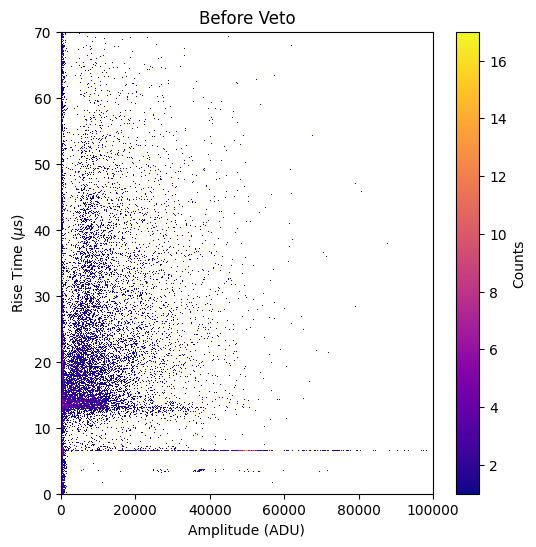

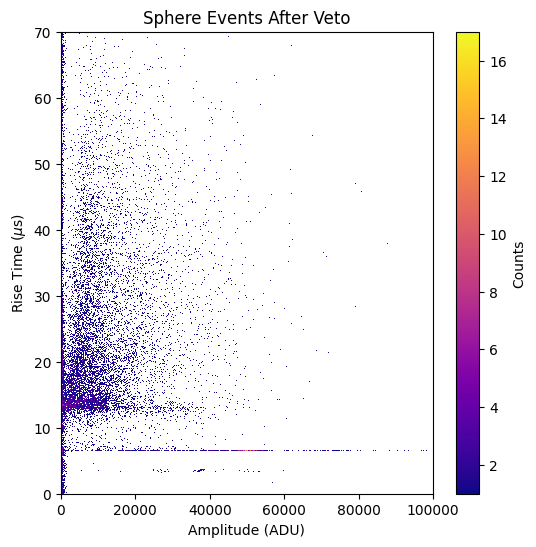

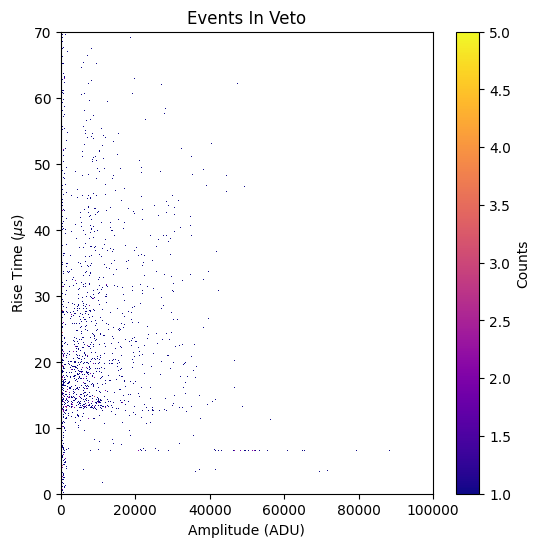

In [3]:
#print the rise-time amplitude plots!
plt.figure(figsize=(6,6))
h = plt.hist2d(
    event_df['summed_amplitude'], 
    event_df['risetime'], 
    bins=500,
    range=[[0,100000],[0,70]],
    density=False, 
    cmap='plasma',
    cmin=1
)
plt.title("Before Veto")
plt.ylabel(f'Rise Time ($\mu$s)')
plt.xlabel('Amplitude (ADU)')
plt.colorbar(h[3], label='Counts')  # colorbar
plt.show()


plt.figure(figsize=(6,6))
h = plt.hist2d(
    events_after_veto_df['summed_amplitude'], 
    events_after_veto_df['risetime'], 
    bins=500,
    range=[[0,100000],[0,70]],
    density=False, 
    cmap='plasma',
    cmin=1
)
plt.title("Sphere Events After Veto")
plt.ylabel(f'Rise Time ($\mu$s)')
plt.xlabel('Amplitude (ADU)')
plt.colorbar(h[3], label='Counts')  # colorbar
plt.show()


plt.figure(figsize=(6,6))
h = plt.hist2d(
    events_which_trigger_veto['summed_amplitude'], 
    events_which_trigger_veto['risetime'], 
    bins=500,
    range=[[0,100000],[0,70]],
    density=False, 
    cmap='plasma',
    cmin=1
)
plt.title("Events In Veto")
plt.ylabel(f'Rise Time ($\mu$s)')
plt.xlabel('Amplitude (ADU)')
plt.colorbar(h[3], label='Counts')  # colorbar
plt.show()

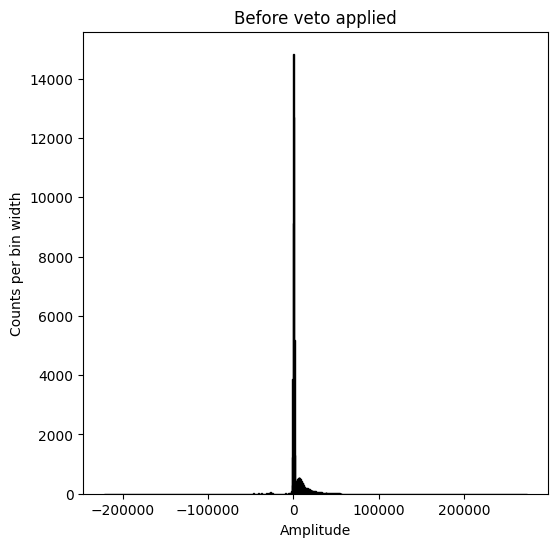

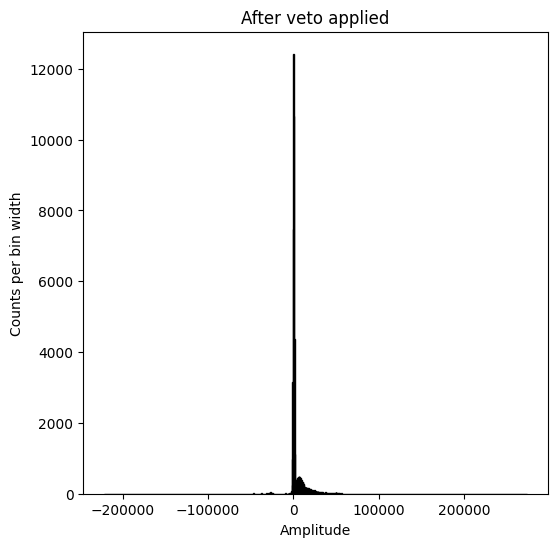

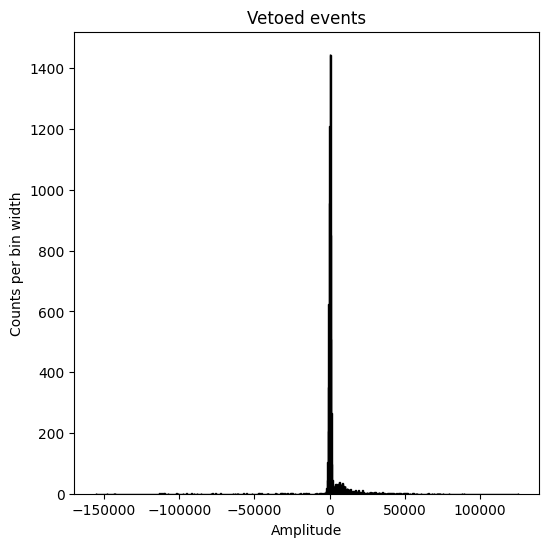

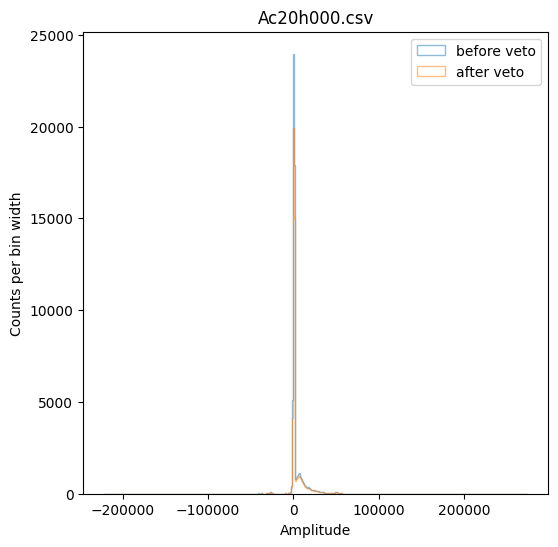

In [4]:
#amplitude histogram

plt.figure(figsize=(6, 6))
plt.hist(event_df['summed_amplitude'], bins=1000, edgecolor='black')
plt.title('Before veto applied')
#plt.xlim(0,40000)
#plt.ylim(0,2000)
plt.xlabel('Amplitude')
plt.ylabel('Counts per bin width')
plt.show()

plt.figure(figsize=(6, 6))
plt.hist(events_after_veto_df['summed_amplitude'], bins=1000, edgecolor='black')
plt.title('After veto applied')
#plt.xlim(0,40000)
#plt.ylim(0,2000)
plt.xlabel('Amplitude')
plt.ylabel('Counts per bin width')
plt.show()

plt.figure(figsize=(6, 6))
plt.hist(events_which_trigger_veto['summed_amplitude'], bins=1000, edgecolor='black')
plt.title('Vetoed events')
#plt.xlim(0,40000)
#plt.ylim(0,2000)
plt.xlabel('Amplitude')
plt.ylabel('Counts per bin width')
plt.show()

plt.figure(figsize=(6,6))
plt.hist(event_df['summed_amplitude'], bins=500, alpha = 0.5,label = 'before veto',histtype='step')
plt.hist(events_after_veto_df['summed_amplitude'], bins=500,alpha = 0.5, label = 'after veto',histtype='step')
#plt.xlim(0, 40000)
plt.xlabel('Amplitude')
#plt.ylim(0, 2000)
plt.ylabel('Counts per bin width') 
plt.title(filename)
plt.legend()

In [5]:
#percentage of muons present in the sphere which were vetoed
#assume muon events are those with amplitudes 3000 to 80000 ADU
lower_amp = 3000
upper_amp = 80000

print('total number of events in this range:', len(event_df[(event_df['summed_amplitude'].abs() >= lower_amp) & (event_df['summed_amplitude'].abs() <= upper_amp)]))

print('total number of events in this range which remain:', len(events_after_veto_df[(events_after_veto_df['summed_amplitude'].abs() >= lower_amp) & (events_after_veto_df['summed_amplitude'].abs() <= upper_amp)]))

print('number vetoed:', len(event_df[(event_df['summed_amplitude'].abs() >= lower_amp) & (event_df['summed_amplitude'].abs() <= upper_amp)]) - len(events_after_veto_df[(events_after_veto_df['summed_amplitude'].abs() >= lower_amp) & (events_after_veto_df['summed_amplitude'].abs() <= upper_amp)]))

print('percentage vetoed:', (1 - len(events_after_veto_df[(events_after_veto_df['summed_amplitude'].abs() >= lower_amp) & (events_after_veto_df['summed_amplitude'].abs() <= upper_amp)]) / len(event_df[(event_df['summed_amplitude'].abs() >= lower_amp) & (event_df['summed_amplitude'].abs() <= upper_amp)])) * 100)



total number of events in this range: 15391
total number of events in this range which remain: 13922
number vetoed: 1469
percentage vetoed: 9.544539016308228


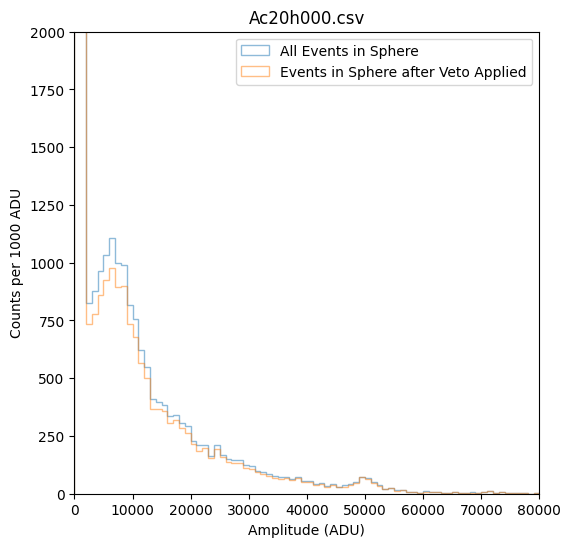

In [17]:
#nice figure
bins = np.arange(0, 80001, 1000)  # 1000 ADU bin width

before = len(event_df[(event_df['summed_amplitude'].abs() >= lower_amp) & (event_df['summed_amplitude'].abs() <= upper_amp)])
after = len(events_after_veto_df[(events_after_veto_df['summed_amplitude'].abs() >= lower_amp) & (events_after_veto_df['summed_amplitude'].abs() <= upper_amp)])
percentage_vetoed = (1 - after / before) * 100

plt.figure(figsize=(6,6))
plt.hist(event_df['summed_amplitude'], bins=bins, alpha = 0.5,label = 'All Events in Sphere',histtype='step')
plt.hist(events_after_veto_df['summed_amplitude'], bins=bins,alpha = 0.5, label = 'Events in Sphere after Veto Applied',histtype='step')
plt.xlim(0, 80000)
plt.xlabel('Amplitude (ADU)')
plt.ylim(0, 2000)
plt.ylabel('Counts per 1000 ADU') 
plt.title(filename)
#plt.text(0.1, 0.95,f'Events in sphere vetoed between {lower_amp}–{upper_amp} ADU: {percentage_vetoed:.2f}%',transform=plt.gca().transAxes,verticalalignment='top')
plt.legend()